# Trabajo Final Visión por Computadora II - CEIA - UBA
## Modelo: ResNet50

**Resumen**

En este notebook se presenta el entrenamiento realizado con la arquitectura **ResNet50** con pesos entrenados con el dataset **ImageNet**, y se comparó su desempeño con el modelo *baseline* correspondiente a la VGG16.

Al igual que en el caso anterior, se utilizó el dataset procesado *(clean)* y se aplicaron técnicas de *data augmentation*, basadas en las transformaciones propuestas durante el EDA.

Si bien se reporta la *accuracy* como referencia, se priorizó el análisis de las métricas *F1-macro* y *recall* por su mayor relevancia clínica. Además, se analizó detalladamente la matriz de confusión para interpretar el comportamiento del modelo por clase.

Se realizaron múltiples experimentos variando los parámetros de entrenamiento. En este notebook se presenta el entrenamiento con el que se obtuvieron los mejores resultados.

**ResNet50** utiliza bloques residuales que permiten entrenar redes muy profundas mediante conexiones de salto (skip connections), lo que facilita el flujo de gradientes y mejora el aprendizaje de características jerárquicas.


## Importar librerías


In [1]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

#!pip install torchmetrics


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.image as mpimg
import random
import os
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torchvision
import torchsummary
from torch.utils.tensorboard import SummaryWriter

from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models


## Carga de datos

Leer carpeta Data_Clean cargada en Drive y verificar su contenido


In [3]:
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')


In [4]:
if IN_COLAB:
    data_dir = '/content/drive/MyDrive/Data_Clean'
else:
    data_dir = './Data_Clean'

if os.path.exists(data_dir):
    print(f"Contenido de {data_dir}:")
    for item in os.listdir(data_dir):
        print(item)
else:
    print(f"El directorio {data_dir} no existe.")

data_dir = Path(data_dir)


Contenido de ./Data_Clean:
test
train
vgg16_baseline_best.pth
valid


In [5]:
random_seed = 42
torch.manual_seed(random_seed)


## Definición de transformaciones

Definición de transformaciones a utilizar para Data Augmentation (propuestas durante el EDA):

* Conversión a **escala de grises**, acorde a la naturaleza de las imágenes de tomografía computada.
* Unificación del **tamaño de imagen** y uso de formatos cuadrados.
* Aplicación de **transformaciones espaciales leves**: rotación de ±10° y variaciones de escala en el rango 0.9–1.1.
* **Flip horizontal aleatorio** (se evita el vertical, que invertiría la orientación anatómica del paciente).
* Variaciones leves de **brillo y contraste**, y **ruido gaussiano suave**, para simular diferencias entre equipos y protocolos de adquisición.
* **Normalización** con los valores de mean y std de ImageNet, necesaria para el uso de pesos preentrenados.


In [6]:
ANCHO_IMAGENES = 224
ALTO_IMAGENES = 224
CANTIDAD_CLASES = 4

# Definir transformaciones para el train set
train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),  # 3 canales porque es lo que espera ResNet
    transforms.Resize(size=(ANCHO_IMAGENES, ALTO_IMAGENES)),
    transforms.RandomRotation(degrees=10),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomResizedCrop(size=(ANCHO_IMAGENES, ALTO_IMAGENES), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))], p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Definir transformaciones para valid y test set
valid_test_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize(size=(ANCHO_IMAGENES, ALTO_IMAGENES)),
    transforms.CenterCrop(size=(ANCHO_IMAGENES, ALTO_IMAGENES)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


## Preparación de datos con ImageFolder - DataLoaders


In [7]:
from torchvision.datasets import ImageFolder

# Crear datasets con ImageFolder
train_dataset = datasets.ImageFolder(root=data_dir / "train", transform=train_transforms)
valid_dataset = datasets.ImageFolder(root=data_dir / "valid", transform=valid_test_transforms)
test_dataset = datasets.ImageFolder(root=data_dir / "test", transform=valid_test_transforms)

batch_size = 32

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size, shuffle=True)
valid_loader = torch.utils.data.DataLoader(valid_dataset, batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size, shuffle=True)

class_names = train_dataset.classes
num_classes = len(class_names)

# Renombrar las clases
class_name_mapping = {
    'adenocarcinoma_left': 'Adenocarcinoma',
    'large.cell.carcinoma_left': 'Large Cell Carcinoma',
    'normal': 'Normal',
    'squamous.cell.carcinoma_left': 'Squamous Cell Carcinoma'
}
class_names = [class_name_mapping.get(name, name) for name in class_names]

print("Clases:", class_names)
print(f"Imágenes train: {len(train_dataset)}")
print(f"Imágenes valid: {len(valid_dataset)}")
print(f"Imágenes test : {len(test_dataset)}")


Clases: ['Adenocarcinoma', 'Large Cell Carcinoma', 'Normal', 'Squamous Cell Carcinoma']
Imágenes train: 577
Imágenes valid: 126
Imágenes test : 128


## Modelo: ResNet50 preentrenada en ImageNet


In [8]:
from torchvision.models import ResNet50_Weights

weights = ResNet50_Weights.IMAGENET1K_V1
resnet50_model = models.resnet50(weights=weights)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet50_model.to(device)

print(resnet50_model)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /home/agustin/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100.0%


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

## Congelar capas convolucionales del modelo base


In [9]:
for param in resnet50_model.parameters():
    param.requires_grad = False


**Fine-tuning parcial**: se utiliza para que la red "desaprenda" lo que es muy específico de ImageNet y pueda especializarse en patrones de imágenes de tomografía. Para esto, además de entrenar el clasificador final, se reentrena también el último bloque convolucional de ResNet50, correspondiente a la capa *layer4*.


In [10]:
# Descongelar solo layer4 (último bloque residual)
for name, param in resnet50_model.named_parameters():
    if "layer4" in name:
        param.requires_grad = True


## Reemplazar última capa fully-connected del clasificador


In [11]:
in_features = resnet50_model.fc.in_features
resnet50_model.fc = torch.nn.Linear(in_features, CANTIDAD_CLASES)

resnet50_model.to(device)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

Solo entrenar las capas con requires_grad=True (en este caso, *layer4* y el clasificador)


In [12]:
params_to_update = [p for p in resnet50_model.parameters() if p.requires_grad]

total_params = sum(p.numel() for p in resnet50_model.parameters())
trainable_params = sum(p.numel() for p in resnet50_model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters: {total_params - trainable_params:,}")


Total parameters: 23,516,228
Trainable parameters: 14,972,932
Frozen parameters: 8,543,296


## Entrenamiento de la red


### Definir optimizador y función de pérdida


In [13]:
num_epochs = 100
lr = 5e-5
weight_decay = 1e-4

loss = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params_to_update, lr=lr, weight_decay=weight_decay)

# Scheduler: reduce el LR si la valid loss no mejora
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# Early stopping: detener entrenamiento si valid_loss no mejora por patience épocas
early_stopping_patience = 10
early_stopping_counter = 0


### Definir función de entrenamiento por época y evaluación


In [14]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


In [15]:
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


### Entrenamiento


In [16]:
import time

best_valid_loss = float("inf")
best_model_wts = None

history = {
    "train_loss": [],
    "train_acc": [],
    "valid_loss": [],
    "valid_acc": [],
}

for epoch in range(num_epochs):
    start = time.time()

    train_loss, train_acc = train_one_epoch(
        resnet50_model, train_loader, loss, optimizer, device
    )
    valid_loss, valid_acc = evaluate(
        resnet50_model, valid_loader, loss, device
    )

    scheduler.step(valid_loss)

    elapsed = time.time() - start

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["valid_loss"].append(valid_loss)
    history["valid_acc"].append(valid_acc)

    print(f"Epoch {epoch+1}/{num_epochs} "
          f"- {elapsed:.1f}s | "
          f"Train loss: {train_loss:.4f}, acc: {train_acc:.4f} | "
          f"Valid loss: {valid_loss:.4f}, acc: {valid_acc:.4f}")

    # Guardar el mejor modelo según valid_loss
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        best_model_wts = resnet50_model.state_dict().copy()
        early_stopping_counter = 0  # Resetear contador cuando hay mejora
        print("  -> Nuevo mejor modelo guardado (mejora valid loss)")
    else:
        early_stopping_counter += 1
        print(f"  -> Sin mejora ({early_stopping_counter}/{early_stopping_patience})")
    
    # Early stopping: detener si no hay mejora por patience épocas
    if early_stopping_counter >= early_stopping_patience:
        print(f"\nEarly stopping activado después de {epoch+1} épocas")
        print(f"No hubo mejora en valid_loss por {early_stopping_patience} épocas consecutivas")
        break

# Cargar mejores pesos
if best_model_wts is not None:
    resnet50_model.load_state_dict(best_model_wts)


Epoch 1/100 - 5.0s | Train loss: 1.1369, acc: 0.4939 | Valid loss: 1.0166, acc: 0.4921
  -> Nuevo mejor modelo guardado (mejora valid loss)
Epoch 2/100 - 4.6s | Train loss: 0.7919, acc: 0.6655 | Valid loss: 0.7001, acc: 0.7063
  -> Nuevo mejor modelo guardado (mejora valid loss)
Epoch 3/100 - 4.6s | Train loss: 0.5033, acc: 0.8631 | Valid loss: 0.3707, acc: 0.8810
  -> Nuevo mejor modelo guardado (mejora valid loss)
Epoch 4/100 - 4.7s | Train loss: 0.3135, acc: 0.9099 | Valid loss: 0.2637, acc: 0.9206
  -> Nuevo mejor modelo guardado (mejora valid loss)
Epoch 5/100 - 4.7s | Train loss: 0.2266, acc: 0.9532 | Valid loss: 0.2136, acc: 0.9365
  -> Nuevo mejor modelo guardado (mejora valid loss)
Epoch 6/100 - 4.7s | Train loss: 0.1523, acc: 0.9636 | Valid loss: 0.1649, acc: 0.9365
  -> Nuevo mejor modelo guardado (mejora valid loss)
Epoch 7/100 - 4.7s | Train loss: 0.1035, acc: 0.9827 | Valid loss: 0.1655, acc: 0.9365
  -> Sin mejora (1/10)
Epoch 8/100 - 4.7s | Train loss: 0.0944, acc: 0.97

### Graficar curva de pérdida y accuracy


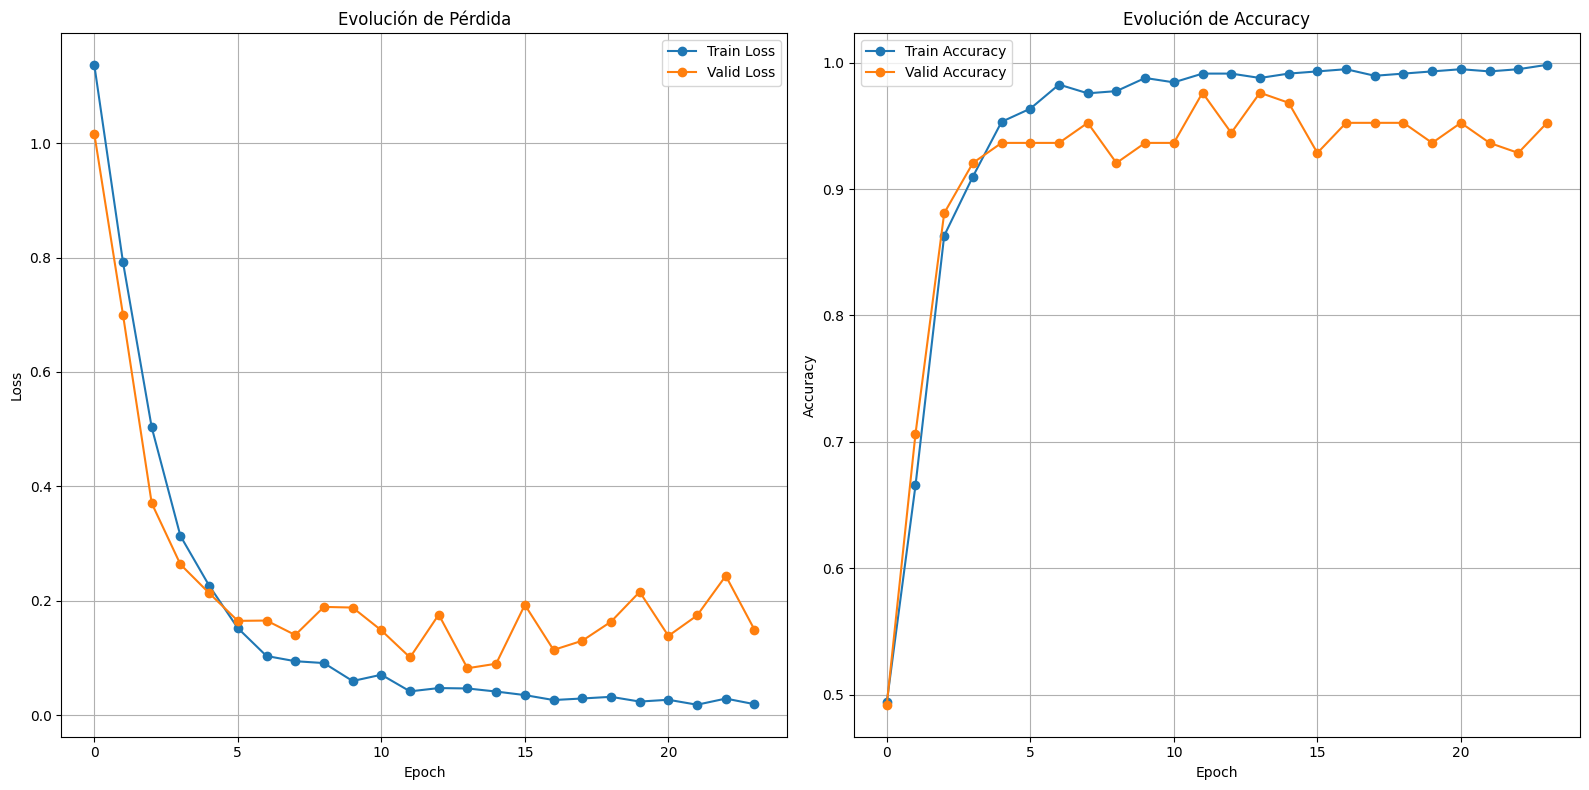

In [17]:
plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train Loss", marker="o")
plt.plot(history["valid_loss"], label="Valid Loss", marker="o")
plt.title("Evolución de Pérdida")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["train_acc"], label="Train Accuracy", marker="o")
plt.plot(history["valid_acc"], label="Valid Accuracy", marker="o")
plt.title("Evolución de Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


## Resultados: evaluación en test


### Pérdida y accuracy


In [18]:
test_loss, test_acc = evaluate(resnet50_model, test_loader, loss, device)
print("\nRESULTADOS FINALES EN TEST")
print(f"Test loss: {test_loss:.4f}")
print(f"Test acc : {test_acc:.4f}")



RESULTADOS FINALES EN TEST
Test loss: 0.1040
Test acc : 0.9688


### Classification report y matriz de confusión



Classification report (TEST) - ResNet50:
                         precision    recall  f1-score   support

         Adenocarcinoma       0.98      0.96      0.97        51
   Large Cell Carcinoma       0.93      1.00      0.97        28
                 Normal       0.91      1.00      0.95        10
Squamous Cell Carcinoma       1.00      0.95      0.97        39

               accuracy                           0.97       128
              macro avg       0.96      0.98      0.97       128
           weighted avg       0.97      0.97      0.97       128



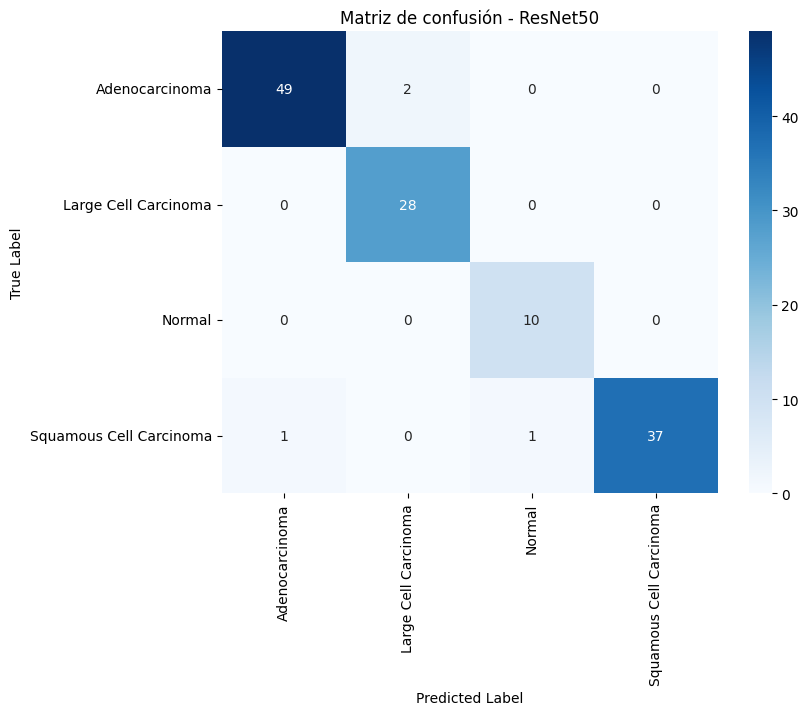

In [19]:
def get_all_preds_and_labels(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return np.array(all_preds), np.array(all_labels)

y_pred, y_true = get_all_preds_and_labels(resnet50_model, test_loader, device)

print("\nClassification report (TEST) - ResNet50:")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Matriz de confusión - ResNet50')
plt.show()


## Guardar el modelo entrenado


In [20]:
model_path = data_dir / "ResNet50_best.pth"
torch.save(resnet50_model.state_dict(), model_path)
print(f"\nModelo guardado en: {model_path}")



Modelo guardado en: Data_Clean/ResNet50_best.pth
